In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import tqdm 
from matplotlib import colors
import seaborn as sns
from spatial_derivative_utiliies import second_derivative_central, first_derivative_central, laplacian_polar

## Progenitor-Neuron Model in Polar Coordinates

Simulating the coupled PDE system:
- $\frac{\partial P}{\partial t} = b(r) + D_P \left( P_{rr} + \frac{1}{r} P_r \right) - v_P \left(N_r + \frac{N}{r}\right) - d(r)P$
- $\frac{\partial N}{\partial t} = D_N \left( N_{rr} + \frac{1}{r} N_r \right) - v_N \left(N_r + \frac{N}{r}\right) + d(r) P - m(r, N) N$

Boundary conditions: No-flux at $r = r_{\text{mouth}}$ and $r = R$

In [2]:
# ============================================================================
# Model Parameter Functions (Customizable)
# ============================================================================

def birth_rate(r, params):
    """Birth rate of progenitors: b(r)."""
    return params['b_0'] * np.exp(-(r - params['R'])**2 / params['sigma']**2)


def differentiation_rate(r, params):
    """Differentiation rate d(r); currently constant."""
    return params['d']


def mortality_rate(r, N, params):
    """Neuron mortality rate m(r, N); currently radius-dependent."""
    return params['m_0'] / np.abs(r- 0.95*params["r_mouth"])


def radial_velocity_P(params):
    """Inward progenitor radial velocity (positive inward)."""
    return params['v_P']


def radial_velocity_N(params):
    """Inward neuron radial velocity (positive inward)."""
    return params['v_N']


# ============================================================================
# Conservative Polar Transport Operator
# ============================================================================

def conservative_polar_transport(u, r, dr, D, v):
    """
    Compute
        (1/r) * d/dr [ r * ( D * u_r + v * u ) ]
    in conservative finite-volume form.

    Zero-flux boundaries are imposed directly by setting face fluxes at both
    domain boundaries to zero, which preserves total mass changes correctly.
    """
    n = len(u)

    # Face radii: r_{i+1/2}
    r_faces = np.empty(n + 1)
    r_faces[1:-1] = 0.5 * (r[:-1] + r[1:])
    r_faces[0] = r[0]
    r_faces[-1] = r[-1]

    # Face-centered u and gradients
    u_faces = np.empty(n + 1)
    u_faces[1:-1] = 0.5 * (u[:-1] + u[1:])
    u_faces[0] = u[0]
    u_faces[-1] = u[-1]

    u_r_faces = np.zeros(n + 1)
    u_r_faces[1:-1] = (u[1:] - u[:-1]) / dr

    # Physical radial flux: F = r * (D*u_r + v*u)
    flux_faces = r_faces * (D * u_r_faces + v * u_faces)

    # No-flux boundaries (inner mouth and outer edge)
    flux_faces[0] = 0.0
    flux_faces[-1] = 0.0

    # Conservative divergence at cell centers
    divergence = (flux_faces[1:] - flux_faces[:-1]) / (r * dr)
    return divergence


# ============================================================================
# PDE Right-Hand Sides: ∂P/∂t and ∂N/∂t
# ============================================================================

def dP_dt(P, r, dr, params):
    """
    ∂P/∂t = (1/r) d/dr[r(D_P P_r + v_P P)] + b(r) - d(r)P
    """
    transport = conservative_polar_transport(
        P, r, dr, D=params['D_P'], v=radial_velocity_P(params)
    )
    birth = birth_rate(r, params)
    d = differentiation_rate(r, params)
    differentiation = -d * P
    return transport + birth + differentiation


def dN_dt(P, N, r, dr, params):
    """
    ∂N/∂t = (1/r) d/dr[r(D_N N_r + v_N N)] + d(r)P - m(r,N)N

    Transport is conservative with explicit zero-flux boundaries.
    """
    transport = conservative_polar_transport(
        N, r, dr, D=params['D_N'], v=radial_velocity_N(params)
    )
    d = differentiation_rate(r, params)
    source = d * P
    m = mortality_rate(r, N, params)
    death = -m * N
    return transport + source + death

In [3]:
# ============================================================================
# Time Integration and Simulation
# ============================================================================

def simulate_progenitor_neuron_model(params, T_final, dt, r_mouth_idx=None, verbose=True):
    """Simulate coupled progenitor-neuron dynamics with forward Euler."""
    r_mouth = params['r_mouth']
    R = params['R']
    nr_grid = params['nr_grid']

    r = np.linspace(r_mouth, R, nr_grid)
    dr = r[1] - r[0]

    nt = int(np.ceil(T_final / dt)) + 1
    times = np.linspace(0, T_final, nt)

    P = params['P_initial'](r) if callable(params['P_initial']) else params['P_initial'].copy()
    N = params['N_initial'](r) if callable(params['N_initial']) else params['N_initial'].copy()

    P_history = np.zeros((nt, nr_grid))
    N_history = np.zeros((nt, nr_grid))
    P_history[0, :] = P
    N_history[0, :] = N

    iterator = tqdm.tqdm(range(1, nt), desc="Simulating") if verbose else range(1, nt)

    for n in iterator:
        dP_dt_vals = dP_dt(P, r, dr, params)
        dN_dt_vals = dN_dt(P, N, r, dr, params)

        P = P + dt * dP_dt_vals
        N = N + dt * dN_dt_vals

        P_history[n, :] = P
        N_history[n, :] = N

    return {
        'r': r,
        'P_history': P_history,
        'N_history': N_history,
        'times': times
    }


def simulate_progenitors_only(params, T_final, dt, r_mouth_idx=None, verbose=True):
    """Simulate progenitor-only dynamics with forward Euler."""
    r_mouth = params['r_mouth']
    R = params['R']
    nr_grid = params['nr_grid']

    r = np.linspace(r_mouth, R, nr_grid)
    dr = r[1] - r[0]

    nt = int(np.ceil(T_final / dt)) + 1
    times = np.linspace(0, T_final, nt)

    P = params['P_initial'](r) if callable(params['P_initial']) else params['P_initial'].copy()

    P_history = np.zeros((nt, nr_grid))
    P_history[0, :] = P

    iterator = tqdm.tqdm(range(1, nt), desc="Simulating") if verbose else range(1, nt)

    for n in iterator:
        dP_dt_vals = dP_dt(P, r, dr, params)
        P = P + dt * dP_dt_vals
        P_history[n, :] = P

    return {
        'r': r,
        'P_history': P_history,
        'times': times
    }


def simulate_neurons_only(params, T_final, dt, P_history, r_mouth_idx=None, verbose=True):
    """Simulate neuron-only dynamics using supplied progenitor history/input."""
    r_mouth = params['r_mouth']
    R = params['R']
    nr_grid = params['nr_grid']

    r = np.linspace(r_mouth, R, nr_grid)
    dr = r[1] - r[0]

    nt = int(np.ceil(T_final / dt)) + 1
    times = np.linspace(0, T_final, nt)

    N = params['N_initial'](r) if callable(params['N_initial']) else params['N_initial'].copy()

    if P_history.shape == (nr_grid,):
        P_history = np.tile(P_history, (nt, 1))
        print("static P_history provided, using same progenitor density for all time steps.")
    elif P_history.shape != (nt, nr_grid):
        raise ValueError(f"P_history has shape {P_history.shape}, expected (nt, nr_grid) or (nr_grid,)")
    else:
        P_history = P_history.copy()
        print("dynamic P_history provided, using progenitor density from each time step.")

    N_history = np.zeros((nt, nr_grid))
    N_history[0, :] = N

    iterator = tqdm.tqdm(range(1, nt), desc="Simulating") if verbose else range(1, nt)

    for n in iterator:
        P = P_history[n - 1, :]
        dN_dt_vals = dN_dt(P, N, r, dr, params)
        N = N + dt * dN_dt_vals
        N_history[n, :] = N

    return {
        'r': r,
        'P_history': P_history,
        'N_history': N_history,
        'times': times
    }

In [4]:
# ============================================================================
# Example: Running the Simulation
# ============================================================================

# Define model parameters
# model_params = {
#     # Geometry
#     'r_mouth':0.14,         # Inner radius (mouth) (normalized as fraction of outer radius)
#     'R': 1,              # Outer radius (jellyfish edge) (normalized to 1)
#     'sigma': 0.1,          # Width of birth rate distribution (normalized)
#     'nr_grid': 100,        # Number of radial grid points
    
#     # Diffusion coefficients
#     'D_P': .00003,            # Progenitor diffusion
#     'D_N': .00003,           # Neuron diffusion

#     # Migration coefficients
#     'v_P': .02,            # Progenitor inward radial velocity
#     'v_N': .02,            # Neuron inward radial velocity
    
#     # Rates
#     'b_0': 0.01,            # Birth rate (constant)
#     'd': 0.02,             # Differentiation rate (constant, allows decoupling)
#     'm_0': 0.003,           # Mortality rate (constant)
    
#     # Initial conditions
#     'P_initial': lambda r: np.zeros_like(r),
#     'N_initial': lambda r: np.zeros_like(r)
# }

# # Time simulation parameters
# T_final = 120.0          # Final simulation time (120 houers = 5 days)
# dt = 0.001               # Time step

# # Run simulation
# print("Starting simulation...")
# solution = simulate_progenitor_neuron_model(model_params, T_final, dt, verbose=True)

# r = solution['r']
# P_history = solution['P_history']
# N_history = solution['N_history']
# times = solution['times']

# print(f"Simulation complete.")
# print(f"Domain: r ∈ [{r[0]:.2f}, {r[-1]:.2f}], {len(r)} grid points")
# print(f"Time: t ∈ [0, {times[-1]:.2f}], {len(times)} time steps")
# print(f"Final max P: {P_history[-1].max():.4f}, Final max N: {N_history[-1].max():.4f}")

In [5]:
# ============================================================================
# Visualization: Spatio-temporal evolution
# ============================================================================

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Plot progenitor density
# im1 = axes[0].contourf(times, r, P_history.T, levels=20, cmap='viridis')
# axes[0].set_xlabel('Time', fontsize=12)
# axes[0].set_ylabel('Radius $r$', fontsize=12)
# axes[0].set_title('Progenitor Density $P(r,t)$', fontsize=12)
# cbar1 = plt.colorbar(im1, ax=axes[0])
# cbar1.set_label('$P$', fontsize=11)

# # Plot neuron density
# im2 = axes[1].contourf(times, r, N_history.T, levels=20, cmap='plasma')
# axes[1].set_xlabel('Time', fontsize=12)
# axes[1].set_ylabel('Radius $r$', fontsize=12)
# axes[1].set_title('Neuron Density $N(r,t)$', fontsize=12)
# cbar2 = plt.colorbar(im2, ax=axes[1])
# cbar2.set_label('$N$', fontsize=11)

# plt.tight_layout()
# plt.show()

# print("Visualization complete.")

In [6]:
# # ============================================================================
# # Analysis: Diagnostic Checks
# # ============================================================================

# # Check conservation properties (integrated quantities)
# dr_vals = np.diff(r)
# dr_avg = np.mean(dr_vals)

# # Compute total progenitors and neurons over time (integral approximation)
# # Using trapezoid rule with radial weighting for polar coordinates: ∫P dV = ∫P * 2πr dr
# P_total = np.zeros(len(times))
# N_total = np.zeros(len(times))

# for n in range(len(times)):
#     # Weight by 2πr for integration in polar coordinates
#     radial_weight = 2 * np.pi * r
#     P_total[n] = np.trapz(P_history[n, :] * radial_weight, r)
#     N_total[n] = np.trapz(N_history[n, :] * radial_weight, r)

# fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# # Total progenitors over time
# axes[0].plot(times, P_total, 'b-', linewidth=2)
# axes[0].set_xlabel('Time', fontsize=12)
# axes[0].set_ylabel('Total Progenitors $\\int P \\, dV$', fontsize=12)
# axes[0].set_title('Conservation Check: Total Progenitor Population', fontsize=12)
# axes[0].grid(True, alpha=0.3)

# # Total neurons over time
# axes[1].plot(times, N_total, 'r-', linewidth=2)
# axes[1].set_xlabel('Time', fontsize=12)
# axes[1].set_ylabel('Total Neurons $\\int N \\, dV$', fontsize=12)
# axes[1].set_title('Conservation Check: Total Neuron Population', fontsize=12)
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# print("Diagnostics:")
# print(f"Initial total progenitors: {P_total[0]:.4f}")
# print(f"Final total progenitors:   {P_total[-1]:.4f}")
# print(f"Initial total neurons:     {N_total[0]:.4f}")
# print(f"Final total neurons:       {N_total[-1]:.4f}")

In [7]:
# # ============================================================================
# # Visualization: Radial profiles at selected times
# # ============================================================================

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Select time snapshots to plot
# time_indices = [0, len(times)//4, len(times)//2, 3*len(times)//4, -1]
# colors = plt.cm.twilight(np.linspace(0, 1, len(time_indices)))

# # Progenitor profiles
# for idx, (t_idx, color) in enumerate(zip(time_indices, colors)):
#     label = f'$t = {times[t_idx]:.2f}$'
#     axes[0].plot(r, P_history[t_idx, :], color=color, label=label, linewidth=2)

# axes[0].set_xlabel('Radius $r$', fontsize=12)
# axes[0].set_ylabel('Progenitor Density $P(r)$', fontsize=12)
# axes[0].set_title('Progenitor Profiles at Different Times', fontsize=12)
# axes[0].legend(fontsize=10)
# axes[0].grid(True, alpha=0.3)

# # Neuron profiles
# for idx, (t_idx, color) in enumerate(zip(time_indices, colors)):
#     label = f'$t = {times[t_idx]:.2f}$'
#     axes[1].plot(r, N_history[t_idx, :], color=color, label=label, linewidth=2)

# axes[1].set_xlabel('Radius $r$', fontsize=12)
# axes[1].set_ylabel('Neuron Density $N(r)$', fontsize=12)
# axes[1].set_title('Neuron Profiles at Different Times', fontsize=12)
# axes[1].legend(fontsize=10)
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# print("Profile visualization complete.")

In [8]:
# ============================================================================
# Example: Running the Progenitor-only Simulation
# ============================================================================

# Define model parameters
model_params = {
    # Geometry
    'r_mouth':0.14,         # Inner radius (mouth) (normalized as fraction of outer radius)
    'R': 1,              # Outer radius (jellyfish edge) (normalized to 1)
    'sigma': 0.2,          # Width of birth rate distribution (normalized)
    'nr_grid': 100,        # Number of radial grid points
    
    # Diffusion coefficients
    'D_P': .00003,            # Progenitor diffusion
    'D_N': .00003,           # Neuron diffusion

    # Migration coefficients
    'v_P': .003,            # Progenitor inward radial velocity
    'v_N': .003,            # Neuron inward radial velocity
    
    # Rates
    'b_0': 3,            # Birth rate (constant)
    'd': 0.03,             # Differentiation rate (constant, allows decoupling)
    'm_0': 0.002,           # Mortality rate (multiplies 1/r)
    
    # Initial conditions
    'P_initial': lambda r: np.zeros_like(r),
    'N_initial': lambda r: np.zeros_like(r)
}

# Time simulation parameters
T_final = 400     
dt = 0.001               # Time step

# Run simulation
print("Starting simulation...")
solution = simulate_progenitors_only(model_params, T_final, dt, verbose=True)

r = solution['r']
P_history = solution['P_history']
times = solution['times']

print(f"Simulation complete.")
print(f"Domain: r ∈ [{r[0]:.2f}, {r[-1]:.2f}], {len(r)} grid points")
print(f"Time: t ∈ [0, {times[-1]:.2f}], {len(times)} time steps")
print(f"Final max P: {P_history[-1].max():.4f}")

Starting simulation...


Simulating: 100%|██████████| 400000/400000 [00:08<00:00, 49295.95it/s]

Simulation complete.
Domain: r ∈ [0.14, 1.00], 100 grid points
Time: t ∈ [0, 400.00], 400001 time steps
Final max P: 64.1621


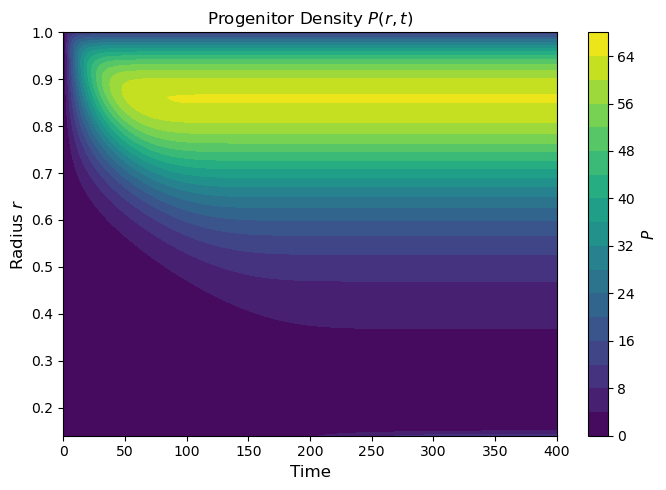

Visualization complete.


In [9]:
# ============================================================================
# Visualization: Spatio-temporal evolution
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

#subsample for faster plotting 
nt = T_final/dt + 1
n_sample_times = 200
sample_indices = np.linspace(0, int(nt)-1, n_sample_times, dtype=int)
times_sampled = times[sample_indices]
P_history_sampled = P_history[sample_indices, :]



# Plot progenitor density
im1 = ax.contourf(times_sampled, r, P_history_sampled.T, levels=20, cmap='viridis')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Radius $r$', fontsize=12)
ax.set_title('Progenitor Density $P(r,t)$', fontsize=12)
cbar1 = plt.colorbar(im1, ax=ax)
cbar1.set_label('$P$', fontsize=11)



plt.tight_layout()
plt.show()

print("Visualization complete.")

/var/folders/87/w43tb79n67n08xyspfl0n8390zhhg9/T/ipykernel_40610/2705121384.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_total[n] = np.trapz(P_history_sampled[n, :] * radial_weight, r)


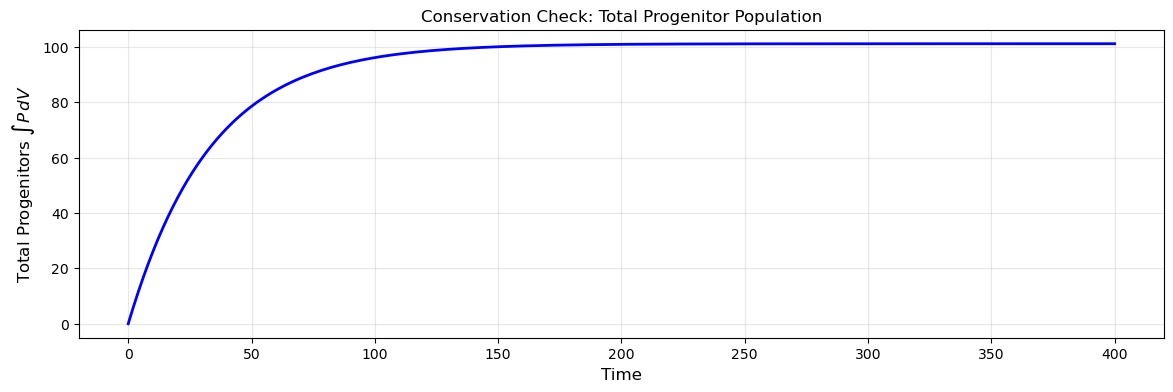

In [10]:
# ============================================================================
# Analysis: Totals
# ============================================================================

# Check conservation properties (integrated quantities)
dr_vals = np.diff(r)
dr_avg = np.mean(dr_vals)

# Compute total progenitors and neurons over time (integral approximation)
# Using trapezoid rule with radial weighting for polar coordinates: ∫P dV = ∫P * 2πr dr
P_total = np.zeros(len(times_sampled))
N_total = np.zeros(len(times_sampled))

for n in range(len(times_sampled)):
    # Weight by 2πr for integration in polar coordinates
    radial_weight = 2 * np.pi * r
    P_total[n] = np.trapz(P_history_sampled[n, :] * radial_weight, r)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))

# Total progenitors over time
ax.plot(times_sampled, P_total, 'b-', linewidth=2)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Total Progenitors $\\int P \\, dV$', fontsize=12)
ax.set_title('Conservation Check: Total Progenitor Population', fontsize=12)
ax.grid(True, alpha=0.3)



Starting simulation...
static P_history provided, using same progenitor density for all time steps.


Simulating: 100%|██████████| 120000/120000 [00:02<00:00, 45425.93it/s]

Simulation complete.
Domain: r ∈ [0.14, 1.00], 100 grid points
Time: t ∈ [0, 120.00], 120001 time steps
Final max P: 64.1621


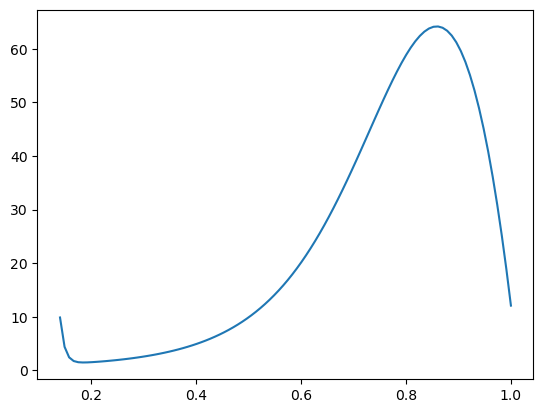

In [11]:
# ============================================================================
# Example: Running the neuron-only Simulation with Progenitor Input
# ============================================================================


# Time simulation parameters
T_final = 120        # Final simulation time (120 hours = 5 days)
dt = 0.001               # Time step

# Run simulation
print("Starting simulation...")
P = P_history[-1, :]
plt.plot(r, P, label='Progenitor Density at Initial Time')
solution = simulate_neurons_only(model_params, T_final, dt, P, verbose=True)

r = solution['r']

times = solution['times']
P_history = solution['P_history']
N_history = solution['N_history']

print(f"Simulation complete.")
print(f"Domain: r ∈ [{r[0]:.2f}, {r[-1]:.2f}], {len(r)} grid points")
print(f"Time: t ∈ [0, {times[-1]:.2f}], {len(times)} time steps")
print(f"Final max P: {P_history[-1].max():.4f}")

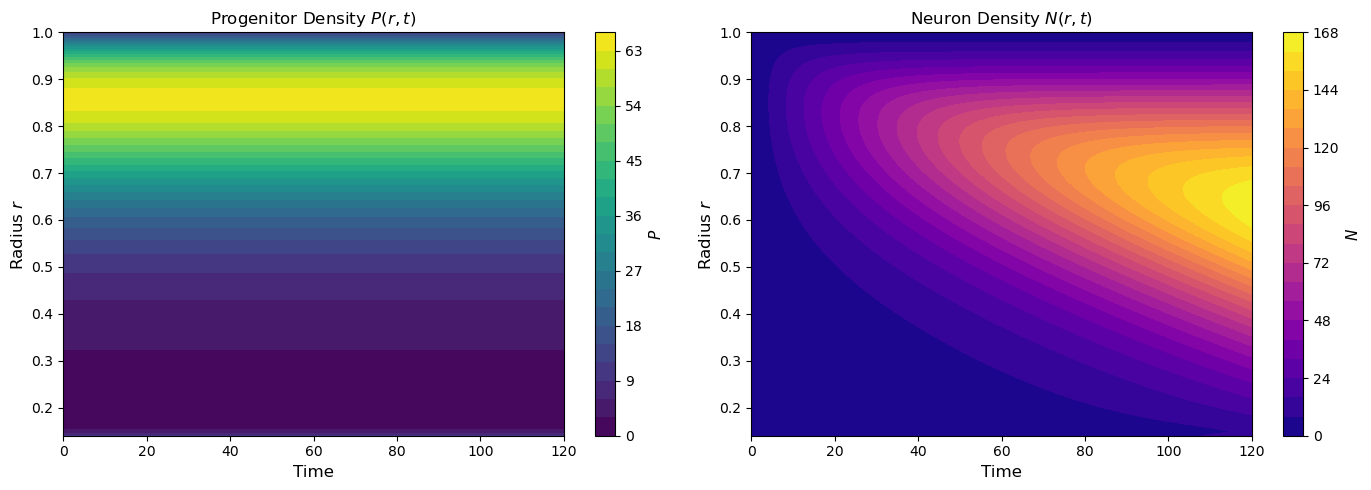

Visualization complete.


In [12]:
# ============================================================================
# Visualization: Spatio-temporal evolution
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#subsample for faster plotting 
nt = T_final/dt + 1
n_sample_times = 200
sample_indices = np.linspace(0, int(nt)-1, n_sample_times, dtype=int)
times_sampled = times[sample_indices]
P_history_sampled = P_history[sample_indices, :]
N_history_sampled = N_history[sample_indices, :]

# Plot progenitor density
im1 = axes[0].contourf(times_sampled, r, P_history_sampled.T, levels=20, cmap='viridis')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('Radius $r$', fontsize=12)
axes[0].set_title('Progenitor Density $P(r,t)$', fontsize=12)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('$P$', fontsize=11)

# Plot neuron density
im2 = axes[1].contourf(times_sampled, r, N_history_sampled.T, levels=20, cmap='plasma')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Radius $r$', fontsize=12)
axes[1].set_title('Neuron Density $N(r,t)$', fontsize=12)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('$N$', fontsize=11)

plt.tight_layout()
plt.show()

print("Visualization complete.")

/var/folders/87/w43tb79n67n08xyspfl0n8390zhhg9/T/ipykernel_40610/2015788568.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_total[n] = np.trapz(P_history_sampled[n, :] * radial_weight, r)
/var/folders/87/w43tb79n67n08xyspfl0n8390zhhg9/T/ipykernel_40610/2015788568.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  N_total[n] = np.trapz(N_history_sampled[n, :] * radial_weight, r)


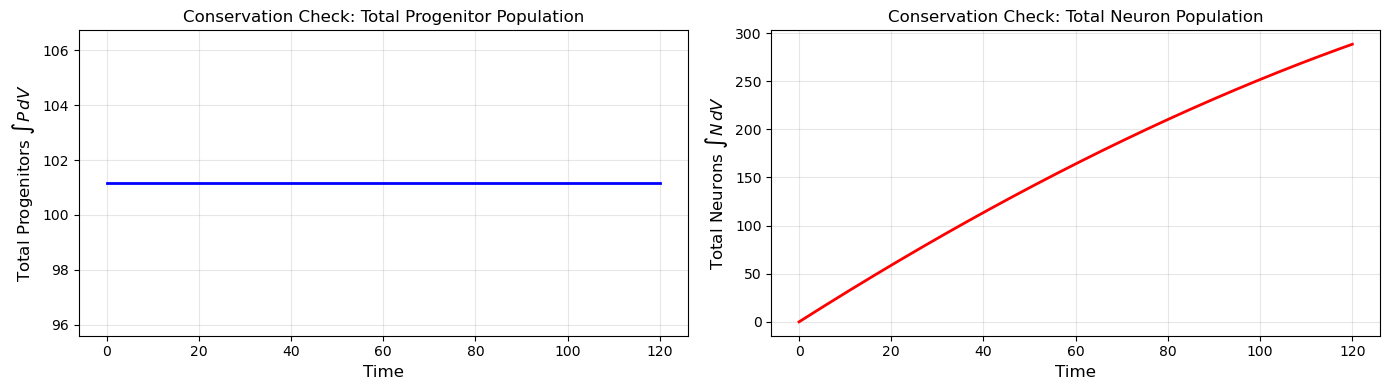

Diagnostics:
Initial total progenitors: 101.1649
Final total progenitors:   101.1649
Initial total neurons:     0.0000
Final total neurons:       288.3943


In [13]:
# ============================================================================
# Analysis: totals
# ============================================================================
#subsample for faster plotting 
nt = T_final/dt + 1
n_sample_times = 200
sample_indices = np.linspace(0, int(nt)-1, n_sample_times, dtype=int)
times_sampled = times[sample_indices]
P_history_sampled = P_history[sample_indices, :]
N_history_sampled = N_history[sample_indices, :]

# Check conservation properties (integrated quantities)
dr_vals = np.diff(r)
dr_avg = np.mean(dr_vals)

# Compute total progenitors and neurons over time (integral approximation)
# Using trapezoid rule with radial weighting for polar coordinates: ∫P dV = ∫P * 2πr dr
P_total = np.zeros(len(times_sampled))
N_total = np.zeros(len(times_sampled))

for n in range(len(times_sampled)):
    # Weight by 2πr for integration in polar coordinates
    radial_weight = 2 * np.pi * r
    P_total[n] = np.trapz(P_history_sampled[n, :] * radial_weight, r)
    N_total[n] = np.trapz(N_history_sampled[n, :] * radial_weight, r)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Total progenitors over time
axes[0].plot(times_sampled, P_total, 'b-', linewidth=2)
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('Total Progenitors $\\int P \\, dV$', fontsize=12)
axes[0].set_title('Conservation Check: Total Progenitor Population', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Total neurons over time
axes[1].plot(times_sampled, N_total, 'r-', linewidth=2)
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Total Neurons $\\int N \\, dV$', fontsize=12)
axes[1].set_title('Conservation Check: Total Neuron Population', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Diagnostics:")
print(f"Initial total progenitors: {P_total[0]:.4f}")
print(f"Final total progenitors:   {P_total[-1]:.4f}")
print(f"Initial total neurons:     {N_total[0]:.4f}")
print(f"Final total neurons:       {N_total[-1]:.4f}")

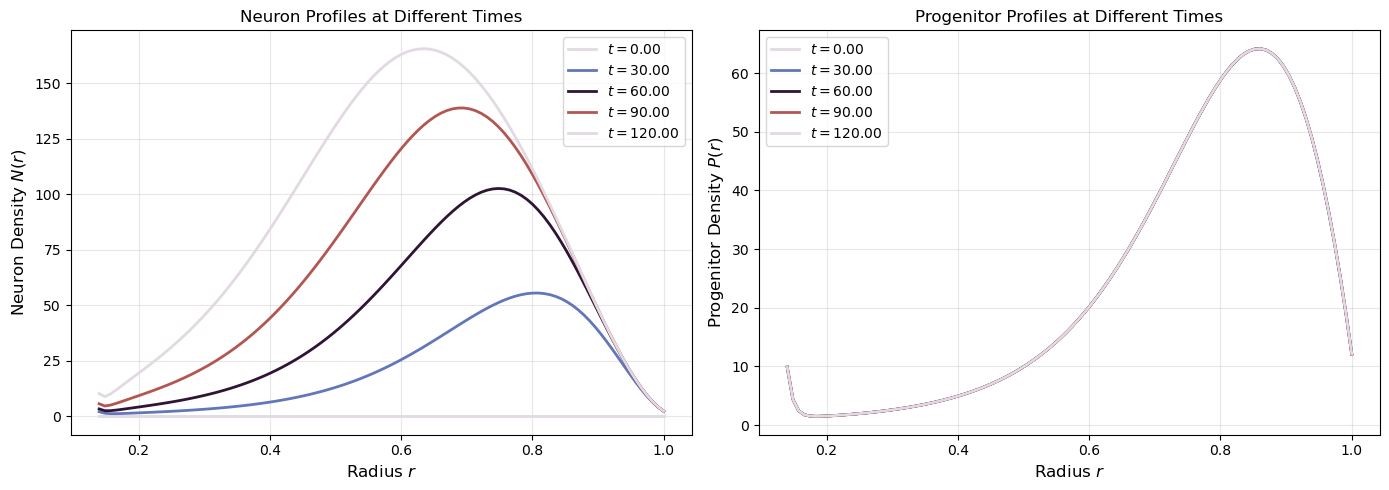

In [14]:
# ============================================================================
# Visualization: Radial profiles at selected times
# ============================================================================
time_indices = [0, len(times)//4, len(times)//2, 3*len(times)//4, -1]
cols = plt.cm.twilight(np.linspace(0, 1, len(time_indices)))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Neuron profiles
for idx, (t_idx, color) in enumerate(zip(time_indices, cols)):
    label = f'$t = {times[t_idx]:.2f}$'
    axes[0].plot(r, N_history[t_idx, :], color=color, label=label, linewidth=2)

axes[0].set_xlabel('Radius $r$', fontsize=12)
axes[0].set_ylabel('Neuron Density $N(r)$', fontsize=12)
axes[0].set_title('Neuron Profiles at Different Times', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Select time snapshots to plot

# Progenitor profiles
for idx, (t_idx, color) in enumerate(zip(time_indices, cols)):
    label = f'$t = {times[t_idx]:.2f}$'
    axes[1].plot(r, P_history[t_idx, :], color=color, label=label, linewidth=2)

axes[1].set_xlabel('Radius $r$', fontsize=12)
axes[1].set_ylabel('Progenitor Density $P(r)$', fontsize=12)
axes[1].set_title('Progenitor Profiles at Different Times', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()



## Real sims for brady

In [15]:
# simulation for brady. same as before, but up-regulate progenitor birth rate at simulation start 
# first, let progens stabilise at lower number, then up-regulate birth rate and see how system responds.


# Define model parameters
model_params = {
    # Geometry
    'r_mouth':0.14,         # Inner radius (mouth) (normalized as fraction of outer radius)
    'R': 1,              # Outer radius (jellyfish edge) (normalized to 1)
    'sigma': 0.2,          # Width of birth rate distribution (normalized)
    'nr_grid': 100,        # Number of radial grid points
    
    # Diffusion coefficients
    'D_P': .00003,            # Progenitor diffusion
    'D_N': .00003,           # Neuron diffusion

    # Migration coefficients
    'v_P': .001,            # Progenitor inward radial velocity
    'v_N': .003,            # Neuron inward radial velocity
    
    # Rates
    'b_0': 1.5,            # Birth rate (constant)
    'd': 0.03,             # Differentiation rate (constant, allows decoupling)
    'm_0': 0.002,           # Mortality rate (multiplies 1/r)
    
    # Initial conditions
    'P_initial': lambda r: np.zeros_like(r),
    'N_initial': lambda r: np.zeros_like(r)
}

# Time simulation parameters
T_final = 400     
dt = 0.001               # Time step

# Run simulation
print("Starting simulation...")
solution = simulate_progenitors_only(model_params, T_final, dt, verbose=True)

r = solution['r']
P_history = solution['P_history']
times = solution['times']

print(f"Simulation complete.")
print(f"Domain: r ∈ [{r[0]:.2f}, {r[-1]:.2f}], {len(r)} grid points")
print(f"Time: t ∈ [0, {times[-1]:.2f}], {len(times)} time steps")
print(f"Final max P: {P_history[-1].max():.4f}")

Starting simulation...


Simulating: 100%|██████████| 400000/400000 [00:08<00:00, 48531.73it/s]

Simulation complete.
Domain: r ∈ [0.14, 1.00], 100 grid points
Time: t ∈ [0, 400.00], 400001 time steps
Final max P: 39.6969


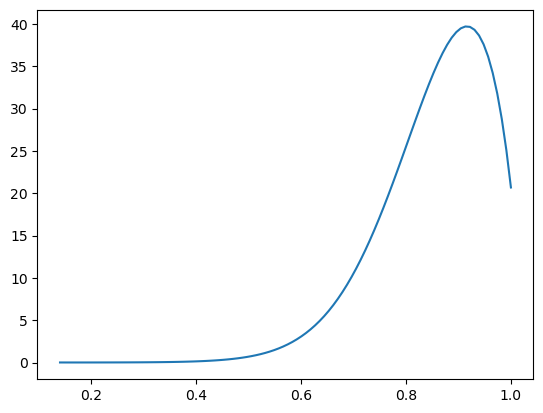

In [16]:
P = P_history[-1, :]
plt.plot(r, P, label='Progenitor Density at Initial Time')

In [17]:

# Define model parameters
model_params = {
    # Geometry
    'r_mouth':0.14,         # Inner radius (mouth) (normalized as fraction of outer radius)
    'R': 1,              # Outer radius (jellyfish edge) (normalized to 1)
    'sigma': 0.2,          # Width of birth rate distribution (normalized)
    'nr_grid': 100,        # Number of radial grid points
    
    # Diffusion coefficients
    'D_P': .00003,            # Progenitor diffusion
    'D_N': .00003,           # Neuron diffusion

    # Migration coefficients
    'v_P': .003,            # Progenitor inward radial velocity
    'v_N': .003,            # Neuron inward radial velocity
    
    # Rates
    'b_0': 4,            # Birth rate (constant)
    'd': 0.03,             # Differentiation rate (constant, allows decoupling)
    'm_0': 0.002,           # Mortality rate (multiplies 1/r)
    
    # Initial conditions
    'P_initial': P,  # use final progenitor density from previous simulation as initial condition for neuron-only simulation
    'N_initial': lambda r: np.zeros_like(r)
}

# Time simulation parameters
T_final = 120.0          # Final simulation time (120 houers = 5 days)
dt = 0.001               # Time step

# Run simulation
print("Starting simulation...")
solution = simulate_progenitor_neuron_model(model_params, T_final, dt, verbose=True)

r = solution['r']
P_history = solution['P_history']
N_history = solution['N_history']
times = solution['times']

print(f"Simulation complete.")
print(f"Domain: r ∈ [{r[0]:.2f}, {r[-1]:.2f}], {len(r)} grid points")
print(f"Time: t ∈ [0, {times[-1]:.2f}], {len(times)} time steps")
print(f"Final max P: {P_history[-1].max():.4f}, Final max N: {N_history[-1].max():.4f}")

Starting simulation...


Simulating: 100%|██████████| 120000/120000 [00:04<00:00, 25478.57it/s]

Simulation complete.
Domain: r ∈ [0.14, 1.00], 100 grid points
Time: t ∈ [0, 120.00], 120001 time steps
Final max P: 85.5483, Final max N: 208.7772


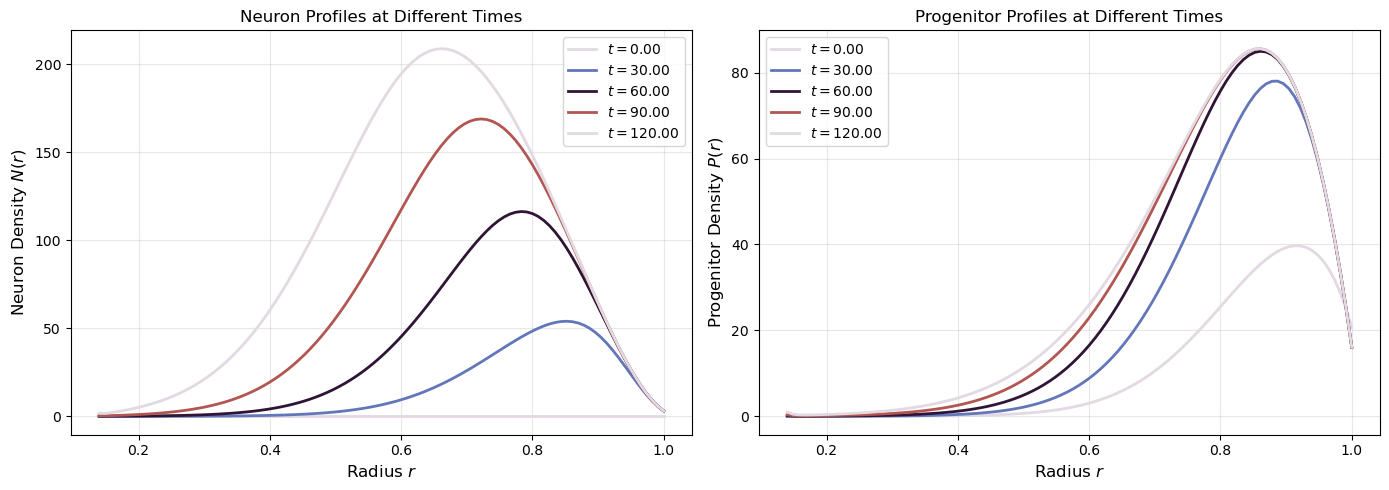

In [18]:
# ============================================================================
# Visualization: Radial profiles at selected times
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Neuron profiles
for idx, (t_idx, color) in enumerate(zip(time_indices, cols)):
    label = f'$t = {times[t_idx]:.2f}$'
    axes[0].plot(r, N_history[t_idx, :], color=color, label=label, linewidth=2)

axes[0].set_xlabel('Radius $r$', fontsize=12)
axes[0].set_ylabel('Neuron Density $N(r)$', fontsize=12)
axes[0].set_title('Neuron Profiles at Different Times', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)



# Progenitor profiles
for idx, (t_idx, color) in enumerate(zip(time_indices, cols)):
    label = f'$t = {times[t_idx]:.2f}$'
    axes[1].plot(r, P_history[t_idx, :], color=color, label=label, linewidth=2)

axes[1].set_xlabel('Radius $r$', fontsize=12)
axes[1].set_ylabel('Progenitor Density $P(r)$', fontsize=12)
axes[1].set_title('Progenitor Profiles at Different Times', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()



/var/folders/87/w43tb79n67n08xyspfl0n8390zhhg9/T/ipykernel_40610/177564703.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_total[n] = np.trapz(P_history_sampled[n, :] * radial_weight, r)
/var/folders/87/w43tb79n67n08xyspfl0n8390zhhg9/T/ipykernel_40610/177564703.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  N_total[n] = np.trapz(N_history_sampled[n, :] * radial_weight, r)


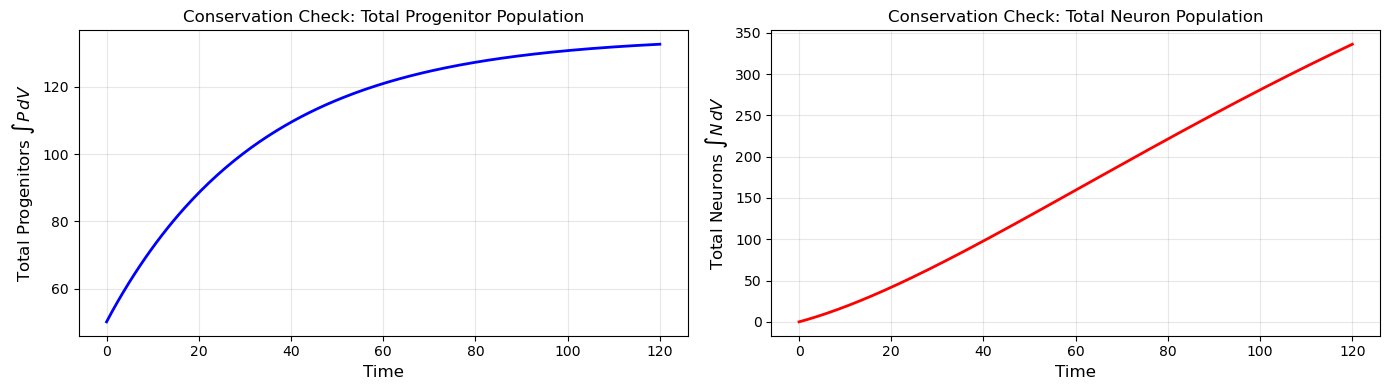

Diagnostics:
Initial total progenitors: 50.2020
Final total progenitors:   132.6221
Initial total neurons:     0.0000
Final total neurons:       336.0949


In [19]:
#subsample for faster plotting 
nt = T_final/dt + 1
n_sample_times = 200
sample_indices = np.linspace(0, int(nt)-1, n_sample_times, dtype=int)
times_sampled = times[sample_indices]
P_history_sampled = P_history[sample_indices, :]
N_history_sampled = N_history[sample_indices, :]

# Check conservation properties (integrated quantities)
dr_vals = np.diff(r)
dr_avg = np.mean(dr_vals)

# Compute total progenitors and neurons over time (integral approximation)
# Using trapezoid rule with radial weighting for polar coordinates: ∫P dV = ∫P * 2πr dr
P_total = np.zeros(len(times_sampled))
N_total = np.zeros(len(times_sampled))

for n in range(len(times_sampled)):
    # Weight by 2πr for integration in polar coordinates
    radial_weight = 2 * np.pi * r
    P_total[n] = np.trapz(P_history_sampled[n, :] * radial_weight, r)
    N_total[n] = np.trapz(N_history_sampled[n, :] * radial_weight, r)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Total progenitors over time
axes[0].plot(times_sampled, P_total, 'b-', linewidth=2)
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('Total Progenitors $\\int P \\, dV$', fontsize=12)
axes[0].set_title('Conservation Check: Total Progenitor Population', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Total neurons over time
axes[1].plot(times_sampled, N_total, 'r-', linewidth=2)
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Total Neurons $\\int N \\, dV$', fontsize=12)
axes[1].set_title('Conservation Check: Total Neuron Population', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Diagnostics:")
print(f"Initial total progenitors: {P_total[0]:.4f}")
print(f"Final total progenitors:   {P_total[-1]:.4f}")
print(f"Initial total neurons:     {N_total[0]:.4f}")
print(f"Final total neurons:       {N_total[-1]:.4f}")

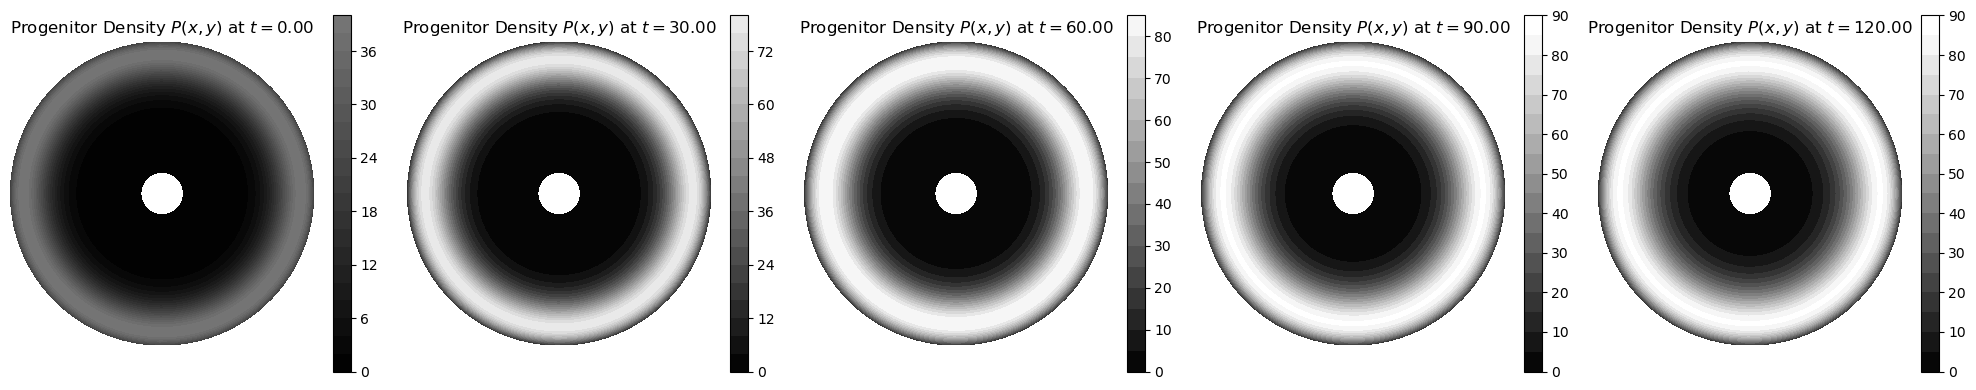

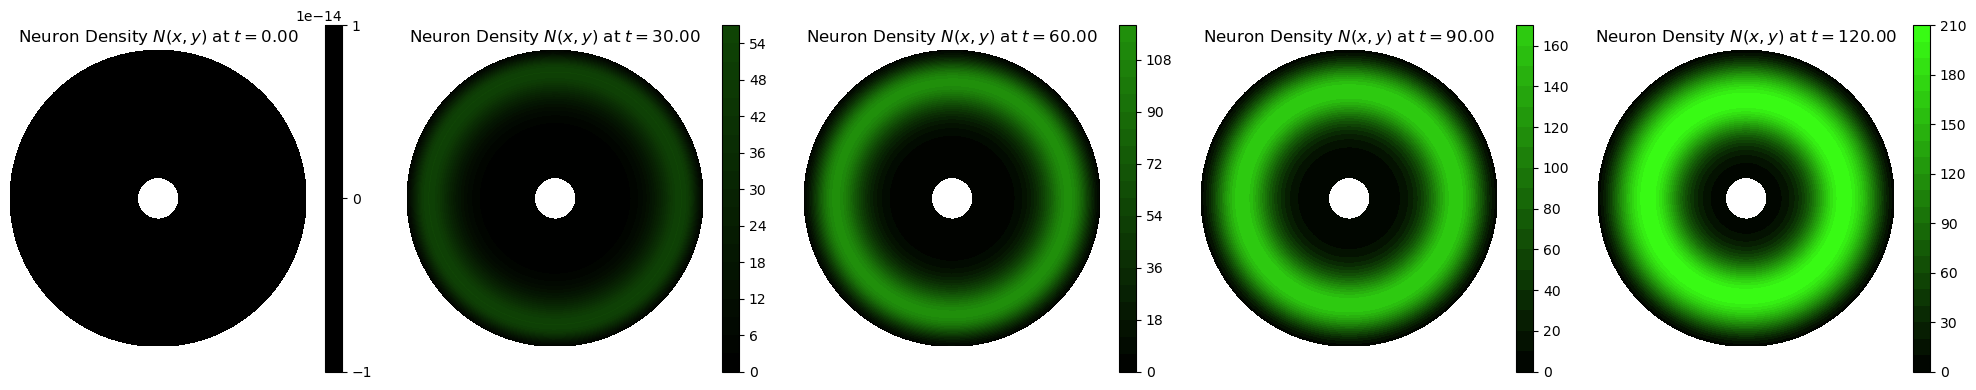

In [20]:
from matplotlib.colors import LinearSegmentedColormap

# for visualization, plot progenitor and neuron densities over time 
# plot on a circular domain, assumping radial symmtery 
# right now, just plot snapshots 
theta_grid = np.linspace(0, 2*np.pi, 100)
x_vals = r * np.cos(theta_grid[:, None])  # shape (ntheta, nr)
y_vals = r * np.sin(theta_grid[:, None])  # shape (ntheta, nr)

# Plot progenitor density
plot_times = [0, len(times)//4, len(times)//2, 3*len(times)//4, -1]
time_indices = [0, len(times)//4, len(times)//2, 3*len(times)//4, -1]
fig, axs = plt.subplots(1, len(time_indices), figsize=(20, 4))
min_density_P = P_history.min()
max_density_P = P_history.max()
norm = colors.Normalize(vmin=min_density_P, vmax=max_density_P)
for idx, t_idx in enumerate(time_indices):
    label = f'$t = {times[t_idx]:.2f}$'
    P_vals_plot = np.tile(P_history[t_idx, :], (len(theta_grid), 1)) 
    im1 = axs[idx].contourf(x_vals, y_vals, P_vals_plot, levels=20, cmap='gist_gray', norm=norm)
    axs[idx].set_aspect('equal')
    axs[idx].set_title(f'Progenitor Density $P(x,y)$ at {label}', fontsize=12)
    cbar1 = plt.colorbar(im1, ax=axs[idx])
    axs[idx].set_axis_off()

    
plt.tight_layout()

GIF_COL_N = '#39FF14'   # neon green  – neurons (GFP)
# Create custom colormap from black to neon green
cmap_N = LinearSegmentedColormap.from_list('black_to_neon', ['black', GIF_COL_N])

# Plot neuron density
plot_times = [0, len(times)//4, len(times)//2, 3*len(times)//4, -1]
time_indices = [0, len(times)//4, len(times)//2, 3*len(times)//4, -1]
fig, axs = plt.subplots(1, len(time_indices), figsize=(20, 4))
min_density_N = N_history.min()
max_density_N = N_history.max()
norm = colors.Normalize(vmin=min_density_N, vmax=max_density_N)
for idx, t_idx in enumerate(time_indices):
    label = f'$t = {times[t_idx]:.2f}$'
    N_vals_plot = np.tile(N_history[t_idx, :], (len(theta_grid), 1)) 
    #cmap = sns.color_palette("rocket", as_cmap=True)
    im1 = axs[idx].contourf(x_vals, y_vals, N_vals_plot, levels=20, cmap=cmap_N, norm=norm)
    axs[idx].set_aspect('equal')
    axs[idx].set_title(f'Neuron Density $N(x,y)$ at {label}', fontsize=12)
    axs[idx].set_axis_off()
    cbar1 = plt.colorbar(im1, ax=axs[idx])


plt.tight_layout()


In [24]:
# Dense sampling for GIF
n_frames = 300  # increase/decrease for smoother/faster GIF
sample_indices = np.linspace(0, len(times) - 1, n_frames, dtype=int)
fps = 20

# Polar-to-Cartesian plotting grid
theta_grid = np.linspace(0, 2 * np.pi, 120)
x_vals = r * np.cos(theta_grid[:, None])
y_vals = r * np.sin(theta_grid[:, None])

# Global color normalization (stable colors across frames)
norm_P = colors.Normalize(vmin=P_history.min(), vmax=P_history.max())
norm_N = colors.Normalize(vmin=N_history.min(), vmax=N_history.max())

fig, (axP, axN) = plt.subplots(1, 2, figsize=(7, 3.2))
fig.subplots_adjust(left=-0.05, right=.9, wspace=0.0, bottom=0.05, top=0.8)
fig.suptitle(f"Model", fontsize=13)

cbarP = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_P, cmap="gray"),
    ax=axP, label="P", fraction=0.046, pad=0.02
)
cbarN = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_N, cmap=cmap_N),
    ax=axN, label="N", fraction=0.046, pad=0.02
)

# Move left plot and its colorbar further left
shift = 0.04
posP = axP.get_position()
cposP = cbarP.ax.get_position()
axP.set_position([posP.x0 - shift, posP.y0, posP.width, posP.height])
cbarP.ax.set_position([cposP.x0 - shift, cposP.y0, cposP.width, cposP.height])

def update(frame_idx):
    t_idx = sample_indices[frame_idx]
    t_val = times[t_idx]

    axP.clear()
    axN.clear()

    P_vals_plot = np.tile(P_history[t_idx, :], (len(theta_grid), 1))
    N_vals_plot = np.tile(N_history[t_idx, :], (len(theta_grid), 1))

    axP.contourf(x_vals, y_vals, P_vals_plot, levels=25, cmap="gray", norm=norm_P)
    axN.contourf(x_vals, y_vals, N_vals_plot, levels=25, cmap=cmap_N, norm=norm_N)

    axP.set_axis_off()
    axN.set_axis_off()
    axP.set_aspect("equal")
    axN.set_aspect("equal")
    axP.set_xticks([])
    axP.set_yticks([])
    axN.set_xticks([])
    axN.set_yticks([])

    axP.set_title(f"Progenitor density, t={t_val:.0f}", fontsize=16)
    axN.set_title(f"Neuron density, t={t_val:.0f}", fontsize=16)

ani = FuncAnimation(fig, update, frames=n_frames, interval=1000 / fps, blit=False)

# Save GIF (requires pillow)
ani.save("../results/progenitor_neuron_dense.gif", writer="pillow", fps=fps)

plt.close(fig)
print("Saved: progenitor_neuron_dense.gif")


Saved: progenitor_neuron_dense.gif
